In [2]:
import torch
import matplotlib.pyplot as plt
import torch.nn.functional as F 
%matplotlib inline


In [3]:
words = open('D:\\NN Andrej Karpathy\\NN andrej karpathy\\part1_bigram\\names.txt', 'r').read().splitlines()
words [:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [4]:
# Build vocabulary of characters and mapping to intergers and vice-versa
characters = sorted(list(set(''.join(words))))
char_to_int = {s:i+1 for i,s in enumerate (characters)}
char_to_int['.'] = 0
int_to_char = {i:s for s,i in char_to_int.items()}
int_to_char




{1: 'a',
 2: 'b',
 3: 'c',
 4: 'd',
 5: 'e',
 6: 'f',
 7: 'g',
 8: 'h',
 9: 'i',
 10: 'j',
 11: 'k',
 12: 'l',
 13: 'm',
 14: 'n',
 15: 'o',
 16: 'p',
 17: 'q',
 18: 'r',
 19: 's',
 20: 't',
 21: 'u',
 22: 'v',
 23: 'w',
 24: 'x',
 25: 'y',
 26: 'z',
 0: '.'}

In [5]:
#  build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?
X, Y = [], []
for w in words: 
    context = [0] * block_size 
    for ch in w + '.': 
        ix = char_to_int[ch] # get the integer representation of the character
        X.append(context) # add the current context to X
        Y.append(ix) # add the target character to Y
        # print(''.join(int_to_char[i] for i in context), '->', int_to_char[ix]) 
        context = context[1:] + [ix] # update the context by removing the first character and adding the new one

X = torch.tensor(X)
Y = torch.tensor(Y)

In [6]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]


In [7]:
sum(p.nelement() for p in parameters)

3481

In [8]:
# CREATING A FUNCTION TO NOT CALL EVERY CELL AGAIN AND AGAIN TO RESET THE MODEL WHEN EVER CALLING THE FORWARD AND BACKWARD PASS

def model_reset():
    def dataset_tr_va_tes(words):    
        block_size = 3 # context length: how many characters do we take to predict the next one?
        X, Y = [], []
        for w in words: 
            context = [0] * block_size 
            for ch in w + '.': 
                ix = char_to_int[ch] # get the integer representation of the character
                X.append(context) # add the current context to X
                Y.append(ix) # add the target character to Y
                # print(''.join(int_to_char[i] for i in context), '->', int_to_char[ix]) 
                context = context[1:] + [ix] # update the context by removing the first character and adding the new one

        X = torch.tensor(X)
        Y = torch.tensor(Y)
        return(X,Y)
    
    import random
    random.seed(42)
    random.shuffle(words)
    n1 = int(0.8*len(words))
    n2 = int(0.9*len(words))

    Xtr, Ytr = dataset_tr_va_tes(words[:n1])
    Xdev, Ydev = dataset_tr_va_tes(words[n1:n2])
    Xte, Yte = dataset_tr_va_tes(words[n2:])    
    

    g = torch.Generator().manual_seed(2147483647) # for reproducibility
    C = torch.randn((27, 10), generator=g)
    W1 = torch.randn((30, 200), generator=g)
    b1 = torch.randn(200, generator=g)
    W2 = torch.randn((200, 27), generator=g)
    b2 = torch.randn(27, generator=g)
    parameters = [C, W1, b1, W2, b2]

    for p in parameters:
        p.requires_grad = True

    return Xtr, Ytr, Xdev, Ydev, Xte, Yte, parameters, C, W1, b1, W2, b2




In [9]:
Xtr, Ytr, Xdev, Ydev, Xte, Yte, parameters, C, W1, b1, W2, b2 = model_reset()

In [10]:
emb = C[Xtr]
h = torch.tanh(emb.view(emb.shape[0], -1) @ W1 + b1)
logits = h @ W2 + b2
counts = logits.exp()
prob = counts / counts.sum(dim=1, keepdim=True)
loss = -prob[torch.arange(len(Xtr)), Ytr].log().mean()
loss


tensor(26.0047, grad_fn=<NegBackward0>)

In [11]:
F.cross_entropy(logits,Ytr)
# It combines the softmax and -ve log likelihood in a more numerically stable way 

tensor(26.0047, grad_fn=<NllLossBackward0>)

In [12]:
# Training Loop
for p in parameters:
    p.requires_grad  = True

# Forward Pass
for i in range(100):
    emb = C[Xtr]
    h = torch.tanh(emb.view(emb.shape[0],-1)@ W1+ b1)
    logits = h @ W2 +b2
    loss = F.cross_entropy(logits,Ytr)

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    #update
    for p in parameters:
        lr = 0.1
        p.data += -lr *p.grad
    
    print(loss.item())

26.004695892333984
24.333492279052734
22.648983001708984
21.391719818115234
21.287694931030273
20.223447799682617
19.25011444091797
18.547449111938477
18.033363342285156
17.545793533325195
17.36294174194336
16.629526138305664
16.110980987548828
15.73495101928711
15.45455551147461
15.574544906616211
14.835092544555664
14.44152545928955
14.157505989074707
13.917322158813477
13.758319854736328
13.405309677124023
13.214301109313965
12.948355674743652
12.715326309204102
12.536218643188477
12.355484008789062
12.197222709655762
12.037761688232422
11.889701843261719
11.743114471435547
11.610907554626465
11.476370811462402
11.359895706176758
11.237964630126953
11.1336030960083
11.022321701049805
10.927899360656738
10.824871063232422
10.738697052001953
10.642438888549805
10.563043594360352
10.472728729248047
10.398895263671875
10.313875198364258
10.244712829589844
10.164448738098145
10.099414825439453
10.023476600646973
9.962287902832031
9.890249252319336
9.832707405090332
9.764103889465332
9.71

In [13]:
# Implementation of Mini - batches to reduce the training time

In [14]:
for p in parameters:
    p.requires_grad  = True

In [15]:
for i in range(1000):

    #minibatch
    ix = torch.randint(0,Xtr.shape[0], (32,))

    # Forward Pass
    emb = C[Xtr[ix]]
    h = torch.tanh(emb.view(emb.shape[0],-1) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Ytr[ix]) # compute the loss for the batch

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    # update
    for p in parameters:
        p.data += -0.1 * p.grad
    
    print(loss.item()) #print loss of batches

8.180633544921875
7.875418663024902
8.852033615112305
8.397573471069336
7.71831750869751
8.688912391662598
9.108263969421387
7.6415534019470215
7.659435749053955
10.96271800994873
9.139423370361328
7.718439102172852
10.535078048706055
11.791719436645508
7.003737449645996
9.905616760253906
10.455957412719727
7.297055244445801
8.831043243408203
8.704314231872559
6.528776168823242
8.428128242492676
5.7980637550354
9.269336700439453
5.804086685180664
10.442323684692383
13.74963665008545
6.532444477081299
9.899435997009277
7.360055446624756
10.666545867919922
6.230330944061279
7.949009895324707
6.7008209228515625
7.089853763580322
8.769610404968262
7.894630432128906
11.490925788879395
5.566988468170166
6.8156256675720215
8.689593315124512
6.564585208892822
8.317258834838867
5.1349687576293945
6.371013164520264
6.899206161499023
6.1498517990112305
8.872726440429688
8.541817665100098
6.701436996459961
7.332984924316406
9.825860977172852
6.826653003692627
7.718558311462402
4.096460819244385
7.

In [16]:
# Loss of training data set
def model_training_loss():         
    emb = C[Xtr] 
    h = torch.tanh(emb.view(emb.shape[0], -1) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Ytr)
    
    return loss.item()

In [17]:
# Loss of Validation data set
def model_val_loss():
    emb = C[Xdev] 
    h = torch.tanh(emb.view(emb.shape[0], -1) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Ydev)

    return loss.item()

In [18]:
# Now to find a good learning rate 
lr_exp = torch.linspace(-3, 0, 1000) # create a range of learning rates from 0.001 to 1
lrs = 10 ** lr_exp # convert the exponent to actual learning rates

In [19]:
for p in parameters:
    p.requires_grad  = True


In [20]:
Xtr, Ytr, Xdev, Ydev, Xte, Yte, parameters, C, W1, b1, W2, b2 = model_reset()

In [21]:
ilr = []
iloss = []


for i in range(1000): # train for 100 iterations

    #minibatch gradient descent
    ix = torch.randint(0, Xtr.shape[0], (32,)) # randomly sample a batch of 32 examples from the dataset

    # forward pass
    emb = C[Xtr[ix]] # embed the characters in the batch of examples to get a 3D tensor of shape (batch_size, block_size, embedding_dim)
    h = torch.tanh(emb.view(emb.shape[0], -1) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Ytr[ix]) # compute the loss for the batch

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    # update
    lr = lrs[i] # get the learning rate for the current iteration
    for p in parameters:
        p.data += -lr * p.grad

    print(loss.item()) # print the loss value at each iteration to monitor training progress

    #track the learning rate and loss for plotting
    ilr.append(lr_exp[i])
    iloss.append(loss.item())
# print(loss.item())

29.24003028869629
29.551591873168945
25.604785919189453
28.93406867980957
28.443986892700195
28.75311851501465
23.36691665649414
23.355697631835938
32.2468147277832
24.01211166381836
27.45258140563965
26.302410125732422
23.38638687133789
21.910207748413086
27.70231819152832
31.006162643432617
28.63897705078125
27.816650390625
23.773677825927734
24.18910789489746
25.207626342773438
26.061248779296875
24.268651962280273
31.18903923034668
26.711074829101562
25.401201248168945
25.18988609313965
24.1951847076416
26.072216033935547
32.87376403808594
22.458356857299805
27.13263702392578
29.04159164428711
25.307695388793945
23.534040451049805
25.158517837524414
23.956811904907227
26.77482032775879
24.104345321655273
27.16943359375
24.084474563598633
21.7565860748291
25.023653030395508
23.85970115661621
24.509199142456055
22.378116607666016
26.20650863647461
24.08021354675293
24.532012939453125
25.842205047607422
29.004470825195312
27.145063400268555
26.90427017211914
22.493906021118164
20.6716

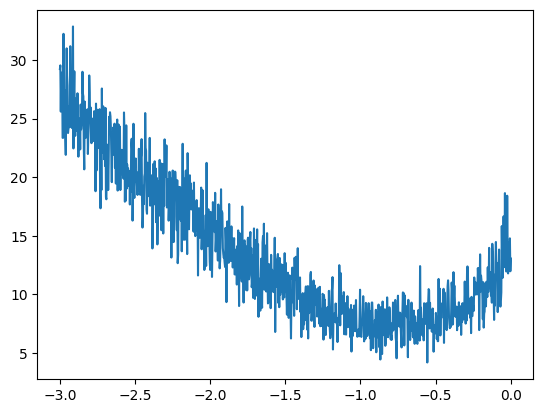

In [22]:
plt.plot(ilr,iloss)

In [23]:
#Loss is lower at a Learning Rate of  somewhat 0.1 so we will choose that. And can also control Learning rate as at later stages of training lower learning rate can be helpful

In [24]:
Xtr, Ytr, Xdev, Ydev, Xte, Yte, parameters, C, W1, b1, W2, b2 = model_reset()

In [25]:
for i in range(200000): 

    #minibatch gradient descent
    ix = torch.randint(0, Xtr.shape[0], (32,)) 

    # forward pass
    emb = C[Xtr[ix]] 
    h = torch.tanh(emb.view(emb.shape[0], -1) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Ytr[ix])

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    # update
    lr = 0.1 if i<100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    # print(loss.item()) 


In [26]:
model_training_loss()

2.1300699710845947

In [27]:
model_val_loss ()

2.1872408390045166

In [28]:
#Sampling

g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    
    out = []
    context = [0] * block_size 
    while True:
      emb = C[torch.tensor([context])] 
      h = torch.tanh(emb.view(1, -1) @ W1 + b1)
      logits = h @ W2 + b2
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break
    
    print(''.join(int_to_char[i] for i in out))

carmahela.
jhqhith.
miliathiyah.
cassie.
rahnee.
amerah.
jareei.
nellarahceriiv.
kaleigh.
ham.
pristeniyah.
roilea.
jadilyn.
jerogiefryxi.
jaxeunivuan.
edde.
iia.
gilee.
yur.
alayas.
